**Desafio do Titanic**

Dicionário:
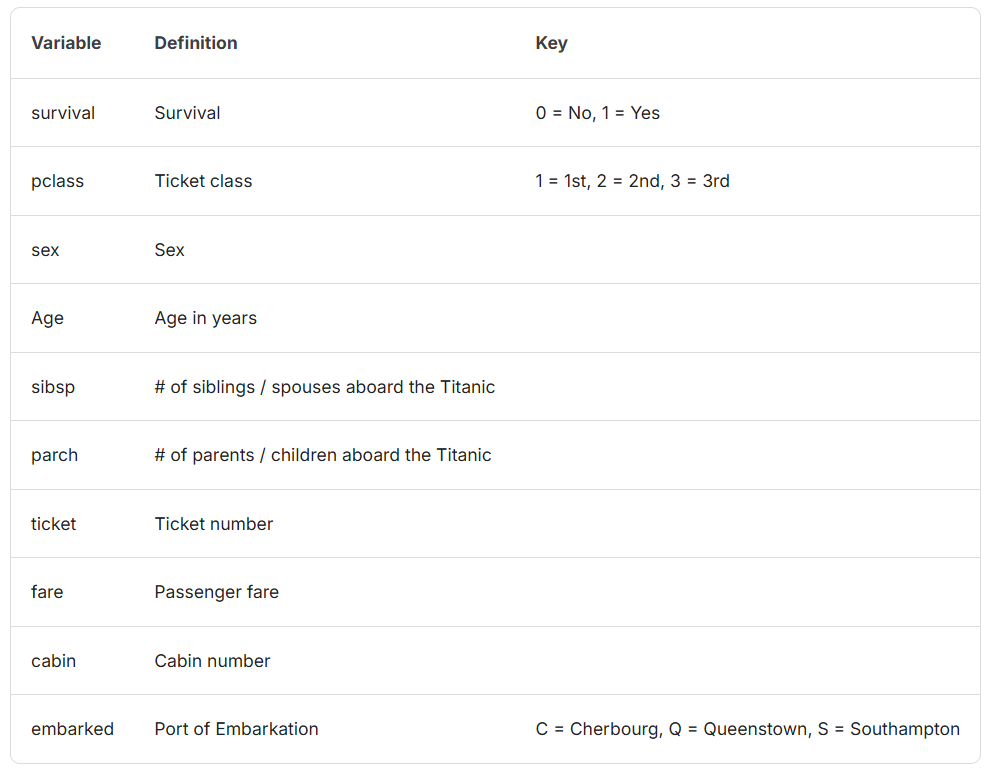![image.png]()


In [2]:
# Import pandas
import pandas as pd

# Load the dataset
train = pd.read_csv('sample_data/train.csv')

# Importing visualization libraries

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
train.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [7]:
train['Survived'].value_counts()

,count
Survived,
0,549
1,342


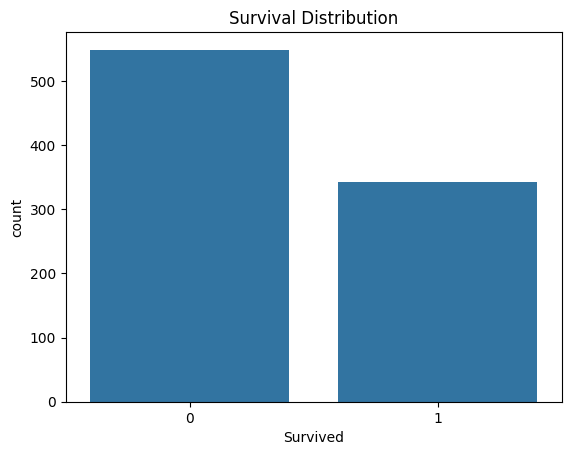

In [8]:
# Visualizing survival distribution

sns.countplot(x='Survived', data=train)

plt.title('Survival Distribution')
plt.show()

In [9]:
train.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


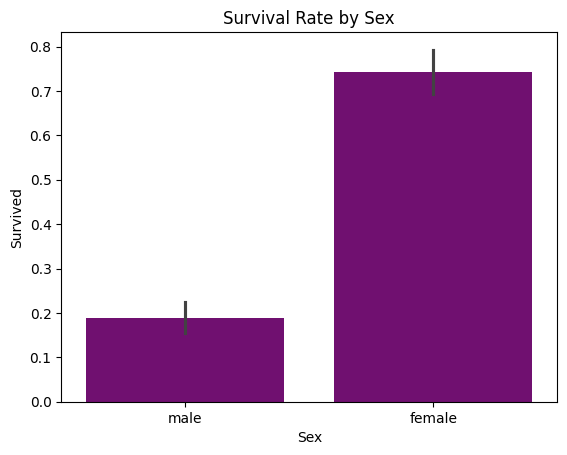

In [10]:
# Visualizing survival rate by sex

sns.barplot(x='Sex', y='Survived', data=train, color='purple')

plt.title('Survival Rate by Sex')
plt.show()

In [11]:
# Grouping passengers by class and calculating the survival rate
train.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


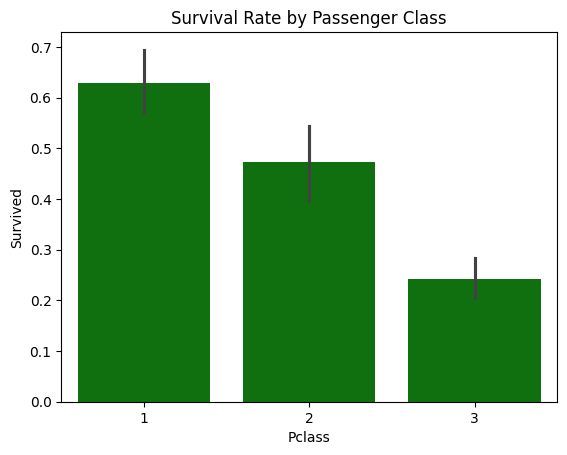

In [12]:
# Visualizing survival rate by passenger class

sns.barplot(x='Pclass', y='Survived', data=train, color='green')

plt.title('Survival Rate by Passenger Class')
plt.show()

In [13]:
# Calculating the survival rate by passenger class and sex
train.groupby(['Pclass','Sex'])['Survived'].mean()

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

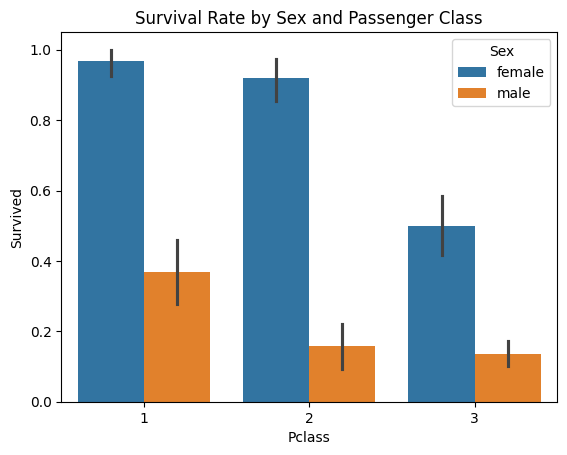

In [14]:
# Visualizing survival rate by sex and passenger class

sns.barplot(
    x='Pclass',
    y='Survived',
    hue='Sex',
    data=train
)

plt.title('Survival Rate by Sex and Passenger Class')
plt.show()

In [15]:
# Calculating survival rate and passenger count by sex and passenger class
train.groupby(['Sex', 'Pclass'])['Survived'].agg(['mean', 'count'])

mean  count
Sex    Pclass                 
female 1       0.968085     94
       2       0.921053     76
       3       0.500000    144
male   1       0.368852    122
       2       0.157407    108
       3       0.135447    347

In [16]:
# Filtering female passengers
teste = train[train['Sex'] == 'female']

In [17]:
# Removing rows with missing values
teste2 = train.dropna()

In [18]:
train.shape

(891, 12)

In [19]:
teste2.shape

(183, 12)

In [20]:
train['Age'].min()

0.42

In [21]:
train['Age'].max()

80.0

In [22]:
# Creating age groups based on passenger age

def categorize_age(age):
    if pd.isna(age):
        return 'Unknown'
    elif age <= 12:
        return 'Child'
    elif age <= 17:
        return 'Teenager'
    elif age <= 59:
        return 'Adult'
    else:
        return 'Elderly'

train['AgeGroup'] = train['Age'].apply(categorize_age)



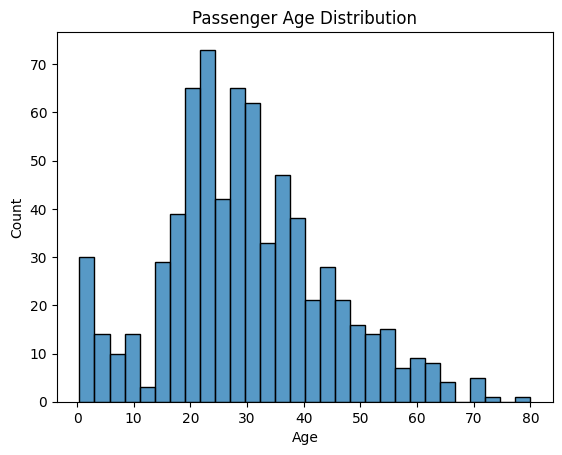

In [23]:
# Visualizing passenger age distribution

sns.histplot(train['Age'], bins=30)

plt.title('Passenger Age Distribution')
plt.xlabel('Age')
plt.show()

In [24]:
display(train.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Adult


In [25]:
# Counting survivors by passenger class, sex, and age group

survivors_by_class_sex_age = train[
    (train['Survived'] == 1)
].groupby(['Pclass', 'Sex', 'AgeGroup'])['Survived'].count()

display(survivors_by_class_sex_age)

Pclass  Sex     AgeGroup
1       female  Adult       72
                Elderly      3
                Teenager     7
                Unknown      9
        male    Adult       34
                Child        3
                Elderly      2
                Teenager     1
                Unknown      5
2       female  Adult       56
                Child        8
                Teenager     4
                Unknown      2
        male    Adult        5
                Child        9
                Elderly      1
                Unknown      2
3       female  Adult       27
                Child       11
                Elderly      1
                Teenager     8
                Unknown     25
        male    Adult       28
                Child        9
                Teenager     1
                Unknown      9
Name: Survived, dtype: int64

In [26]:
# Counting passengers by class, sex, and age group

total_by_class_sex_age = train.groupby(
    ['Pclass', 'Sex', 'AgeGroup']
)['PassengerId'].count()

display(total_by_class_sex_age)

Pclass  Sex     AgeGroup
1       female  Adult        74
                Child         1
                Elderly       3
                Teenager      7
                Unknown       9
        male    Adult        83
                Child         3
                Elderly      14
                Teenager      1
                Unknown      21
2       female  Adult        62
                Child         8
                Teenager      4
                Unknown       2
        male    Adult        84
                Child         9
                Elderly       4
                Teenager      2
                Unknown       9
3       female  Adult        66
                Child        23
                Elderly       1
                Teenager     12
                Unknown      42
        male    Adult       206
                Child        25
                Elderly       4
                Teenager     18
                Unknown      94
Name: PassengerId, dtype: int64

In [27]:
# Calculating the survival rate by passenger class, sex, and age group

survival_rate_by_class_sex_age = train.groupby(
    ['Pclass', 'Sex', 'AgeGroup']
)['Survived'].mean()

display(survival_rate_by_class_sex_age)

Pclass  Sex     AgeGroup
1       female  Adult       0.972973
                Child       0.000000
                Elderly     1.000000
                Teenager    1.000000
                Unknown     1.000000
        male    Adult       0.409639
                Child       1.000000
                Elderly     0.142857
                Teenager    1.000000
                Unknown     0.238095
2       female  Adult       0.903226
                Child       1.000000
                Teenager    1.000000
                Unknown     1.000000
        male    Adult       0.059524
                Child       1.000000
                Elderly     0.250000
                Teenager    0.000000
                Unknown     0.222222
3       female  Adult       0.409091
                Child       0.478261
                Elderly     1.000000
                Teenager    0.666667
                Unknown     0.595238
        male    Adult       0.135922
                Child       0.360000
                Elderly     0.000000
                Teenager    0.055556
                Unknown     0.095745
Name: Survived, dtype: float64

In [28]:
# Filtering female children in first class

female_children_first_class = train[
    (train['Sex'] == 'female') &
    (train['AgeGroup'] == 'Child') &
    (train['Pclass'] == 1)
]

display(female_children_first_class)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
297,298,0,1,"Allison, Miss. Helen Loraine",female,2.0,1,2,113781,151.55,C22 C26,S,Child


In [29]:
# Calculating the median age by passenger class and sex

median_age_by_pclass_sex = train.groupby(
    ['Pclass', 'Sex']
)['Age'].median()

display(median_age_by_pclass_sex)

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

In [30]:
# Calculating the percentage distribution of age groups by passenger class and sex

total_by_class_sex = train.groupby(
    ['Pclass', 'Sex']
).size().reset_index(name='Total')

age_group_counts = train.groupby(
    ['Pclass', 'Sex', 'AgeGroup']
).size().reset_index(name='Count')

merged_df = pd.merge(
    age_group_counts,
    total_by_class_sex,
    on=['Pclass', 'Sex']
)

merged_df['Percentage'] = (
    merged_df['Count'] / merged_df['Total'] * 100
).round(2)

display(
    merged_df.pivot_table(
        index=['Pclass', 'Sex'],
        columns='AgeGroup',
        values='Percentage',
        fill_value=0
    )
)

AgeGroup       Adult  Child  Elderly  Teenager  Unknown
Pclass Sex                                             
1      female  78.72   1.06     3.19      7.45     9.57
       male    68.03   2.46    11.48      0.82    17.21
2      female  81.58  10.53     0.00      5.26     2.63
       male    77.78   8.33     3.70      1.85     8.33
3      female  45.83  15.97     0.69      8.33    29.17
       male    59.37   7.20     1.15      5.19    27.09

In [31]:
# Displaying the percentage distribution of known age groups by passenger class and sex

known_age_groups = merged_df[
    merged_df['AgeGroup'] != 'Unknown'
]

display(
    known_age_groups.pivot_table(
        index=['Pclass', 'Sex'],
        columns='AgeGroup',
        values='Percentage',
        fill_value=0
    )
)

AgeGroup       Adult  Child  Elderly  Teenager
Pclass Sex                                    
1      female  78.72   1.06     3.19      7.45
       male    68.03   2.46    11.48      0.82
2      female  81.58  10.53     0.00      5.26
       male    77.78   8.33     3.70      1.85
3      female  45.83  15.97     0.69      8.33
       male    59.37   7.20     1.15      5.19

In [32]:
# Import numpy
import numpy as np

# Filtering first-class female passengers
group = train[
    (train['Pclass'] == 1) &
    (train['Sex'] == 'female')
]

# Selecting only known age groups
known_groups = group[
    group['AgeGroup'] != 'Unknown'
]

# Calculating age group proportions
proportions = known_groups['AgeGroup'].value_counts(normalize=True)

# Displaying proportions
print(proportions)

# Counting unknown age groups
n_unknown = len(
    group[group['AgeGroup'] == 'Unknown']
)

print(n_unknown)

# Generating probabilistic age group imputations
random_age_groups = np.random.choice(
    proportions.index,
    size=n_unknown,
    p=proportions.values
)

print(random_age_groups)

AgeGroup
Adult       0.870588
Teenager    0.082353
Elderly     0.035294
Child       0.011765
Name: proportion, dtype: float64
9
['Adult' 'Teenager' 'Adult' 'Adult' 'Adult' 'Adult' 'Adult' 'Adult'
 'Adult']


In [33]:
# Filtering all groups except first-class female passengers
other_groups = train[
    ~(
        (train['Pclass'] == 1) &
        (train['Sex'] == 'female')
    )
]

# Selecting only known age groups
known_groups_2 = other_groups[
    other_groups['AgeGroup'] != 'Unknown'
]

# Calculating age group proportions
proportions_2 = known_groups_2['AgeGroup'].value_counts(normalize=True)

# Displaying proportions
print(proportions_2)

# Counting unknown age groups
n_unknown_2 = len(
    other_groups[other_groups['AgeGroup'] == 'Unknown']
)

print(n_unknown_2)

# Generating probabilistic age group imputations
random_age_groups_2 = np.random.choice(
    proportions_2.index,
    size=n_unknown_2,
    p=proportions_2.values
)

print(random_age_groups_2)

AgeGroup
Adult       0.796502
Child       0.108108
Teenager    0.058824
Elderly     0.036566
Name: proportion, dtype: float64
168
['Adult' 'Adult' 'Adult' 'Teenager' 'Adult' 'Adult' 'Teenager' 'Adult'
 'Adult' 'Adult' 'Adult' 'Adult' 'Child' 'Adult' 'Adult' 'Adult' 'Adult'
 'Adult' 'Elderly' 'Adult' 'Adult' 'Adult' 'Child' 'Adult' 'Adult' 'Adult'
 'Adult' 'Adult' 'Teenager' 'Adult' 'Adult' 'Adult' 'Adult' 'Adult'
 'Adult' 'Adult' 'Adult' 'Adult' 'Adult' 'Adult' 'Adult' 'Adult' 'Adult'
 'Elderly' 'Adult' 'Adult' 'Elderly' 'Adult' 'Adult' 'Child' 'Teenager'
 'Child' 'Adult' 'Adult' 'Child' 'Adult' 'Adult' 'Adult' 'Adult' 'Adult'
 'Adult' 'Adult' 'Adult' 'Adult' 'Adult' 'Adult' 'Adult' 'Adult' 'Child'
 'Adult' 'Adult' 'Adult' 'Adult' 'Adult' 'Child' 'Adult' 'Adult' 'Adult'
 'Adult' 'Adult' 'Teenager' 'Adult' 'Adult' 'Adult' 'Adult' 'Elderly'
 'Adult' 'Adult' 'Adult' 'Adult' 'Adult' 'Adult' 'Adult' 'Adult' 'Adult'
 'Child' 'Adult' 'Adult' 'Adult' 'Adult' 'Adult' 'Adult' 'Adult' 'Elderly'
 

In [34]:
# Setting a random seed for reproducibility
np.random.seed(42)

# Creating a copy of the dataframe
train_imputed = train.copy()

# Iterating through passenger classes
for pclass in train['Pclass'].unique():

    # Iterating through sexes
    for sex in train['Sex'].unique():

        # Filtering the current group
        group = train_imputed[
            (train_imputed['Pclass'] == pclass) &
            (train_imputed['Sex'] == sex)
        ]

        # Selecting known age groups
        known_groups = group[
            group['AgeGroup'] != 'Unknown'
        ]

        # Calculating age group probabilities
        proportions = known_groups['AgeGroup'].value_counts(
            normalize=True
        )

        # Finding indices of unknown age groups
        unknown_indices = group[
            group['AgeGroup'] == 'Unknown'
        ].index

        # Counting unknown age groups
        n_unknown = len(unknown_indices)

        # Applying probabilistic imputation only if unknown values exist
        if n_unknown > 0:

            # Generating probabilistic age group imputations
            random_age_groups = np.random.choice(
                proportions.index,
                size=n_unknown,
                p=proportions.values
            )

            # Filling the dataframe with imputed values
            train_imputed.loc[
                unknown_indices,
                'AgeGroup'
            ] = random_age_groups

In [35]:
train_imputed.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889,891
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3,4
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S,Adult
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644,719
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN,NaN


In [36]:
train_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  AgeGroup     891 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 90.6+ KB


In [37]:
# Calculating the age group distribution after probabilistic imputation

total_by_class_sex_imputed = train_imputed.groupby(
    ['Pclass', 'Sex']
).size().reset_index(name='Total')

age_group_counts_imputed = train_imputed.groupby(
    ['Pclass', 'Sex', 'AgeGroup']
).size().reset_index(name='Count')

merged_df_imputed = pd.merge(
    age_group_counts_imputed,
    total_by_class_sex_imputed,
    on=['Pclass', 'Sex']
)

merged_df_imputed['Percentage'] = (
    merged_df_imputed['Count'] /
    merged_df_imputed['Total'] * 100
).round(2)

display(
    merged_df_imputed.pivot_table(
        index=['Pclass', 'Sex'],
        columns='AgeGroup',
        values='Percentage',
        fill_value=0
    )
)

AgeGroup       Adult  Child  Elderly  Teenager
Pclass Sex                                    
1      female  88.30   1.06     3.19      7.45
       male    81.97   4.92    12.30      0.82
2      female  84.21  10.53     0.00      5.26
       male    86.11   8.33     3.70      1.85
3      female  65.97  21.53     0.69     11.81
       male    81.84   9.51     1.44      7.20

In [38]:
# Creating a binary feature indicating whether a cabin number is available

train_imputed['HasCabin'] = (
    train_imputed['Cabin'].notna().astype(int)
)

In [39]:
train_imputed[['Cabin', 'HasCabin']].head()


,Cabin,HasCabin
0,NaN,0
1,C85,1
2,NaN,0
3,C123,1
4,NaN,0


In [40]:
train_imputed['HasCabin'].value_counts()

,count
HasCabin,
0,687
1,204


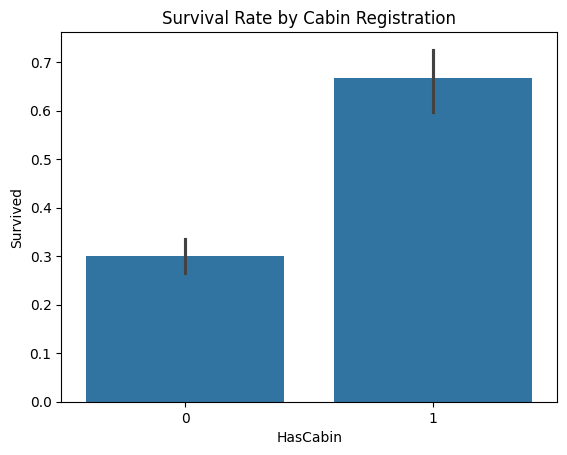

In [41]:
# Visualizing survival rate based on cabin registration

sns.barplot(
    x='HasCabin',
    y='Survived',
    data=train_imputed
)

plt.title('Survival Rate by Cabin Registration')
plt.show()

In [42]:
train_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  AgeGroup     891 non-null    object 
 13  HasCabin     891 non-null    int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 97.6+ KB


In [43]:
# Counting passengers with and without cabin information by passenger class

train_imputed.groupby('Pclass')['HasCabin'].value_counts()

Pclass  HasCabin
1       1           176
        0            40
2       0           168
        1            16
3       0           479
        1            12
Name: count, dtype: int64

In [44]:
train_imputed.groupby('Pclass')['HasCabin'].mean()

,HasCabin
Pclass,
1,0.814815
2,0.086957
3,0.024440


In [45]:
# Removing columns with missing values and unused cabin information

train_imputed_2 = train_imputed.drop(
    columns=['Age', 'Cabin']
)

In [46]:
train_imputed_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Embarked     889 non-null    object 
 10  AgeGroup     891 non-null    object 
 11  HasCabin     891 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 83.7+ KB


In [47]:
# Removing rows with missing embarkation values

train_final = train_imputed_2.dropna(
    subset=['Embarked']
)

In [48]:
train_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   SibSp        889 non-null    int64  
 6   Parch        889 non-null    int64  
 7   Ticket       889 non-null    object 
 8   Fare         889 non-null    float64
 9   Embarked     889 non-null    object 
 10  AgeGroup     889 non-null    object 
 11  HasCabin     889 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 90.3+ KB


In [49]:
# Applying One-Hot Encoding to categorical variables

train_encoded = pd.get_dummies(
    train_final,
    columns=['Sex', 'Embarked', 'AgeGroup'],
    drop_first=True  # "female" and "Teenager" are used as reference categories
)

In [50]:
train_encoded.head()

,PassengerId,Survived,Pclass,Name,SibSp,Parch,Ticket,Fare,HasCabin,Sex_male,Embarked_Q,Embarked_S,AgeGroup_Child,AgeGroup_Elderly,AgeGroup_Teenager
0,1,0,3,"Braund, Mr. Owen Harris",1,0,A/5 21171,7.2500,0,True,False,True,False,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0,PC 17599,71.2833,1,False,False,False,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,0,STON/O2. 3101282,7.9250,0,False,False,True,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0,113803,53.1000,1,False,False,True,False,False,False
4,5,0,3,"Allen, Mr. William Henry",0,0,373450,8.0500,0,True,False,True,False,False,False


In [51]:
train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PassengerId        889 non-null    int64  
 1   Survived           889 non-null    int64  
 2   Pclass             889 non-null    int64  
 3   Name               889 non-null    object 
 4   SibSp              889 non-null    int64  
 5   Parch              889 non-null    int64  
 6   Ticket             889 non-null    object 
 7   Fare               889 non-null    float64
 8   HasCabin           889 non-null    int64  
 9   Sex_male           889 non-null    bool   
 10  Embarked_Q         889 non-null    bool   
 11  Embarked_S         889 non-null    bool   
 12  AgeGroup_Child     889 non-null    bool   
 13  AgeGroup_Elderly   889 non-null    bool   
 14  AgeGroup_Teenager  889 non-null    bool   
dtypes: bool(6), float64(1), int64(6), object(2)
memory usage: 74.7+ KB


In [52]:
# Two columns with "object" dtype remained: "Name" and "Ticket".
# Although these variables may contain useful information, they increase the model complexity at this stage.
#
# "Name" includes passenger titles, which may provide insights such as:
# possible social status, gender, approximate age, and family role.
#
# "Ticket" contains many unique values, inconsistent formats,
# high cardinality, and is difficult to interpret initially.

train_model = train_encoded.drop(columns=['Name', 'Ticket'])

In [53]:
train_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PassengerId        889 non-null    int64  
 1   Survived           889 non-null    int64  
 2   Pclass             889 non-null    int64  
 3   SibSp              889 non-null    int64  
 4   Parch              889 non-null    int64  
 5   Fare               889 non-null    float64
 6   HasCabin           889 non-null    int64  
 7   Sex_male           889 non-null    bool   
 8   Embarked_Q         889 non-null    bool   
 9   Embarked_S         889 non-null    bool   
 10  AgeGroup_Child     889 non-null    bool   
 11  AgeGroup_Elderly   889 non-null    bool   
 12  AgeGroup_Teenager  889 non-null    bool   
dtypes: bool(6), float64(1), int64(6)
memory usage: 60.8 KB


In [54]:
# Separating features (X) and target variable (y)

X = train_model.drop(columns=['Survived'])
y = train_model['Survived']

In [55]:
# Train/Test Split com o modelo Regression Logic
# Splitting the dataset into training and testing sets using Logistic Regression

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  # 20% testing data and 80% training data
    random_state=42  # Controls randomness for reproducibility
)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

In [56]:
# Training the model
# The model analyzes patterns, adjusts weights, and learns relationships between variables

model.fit(X_train, y_train)

# Making predictions on the test set
# The model attempts to predict passenger survival

y_pred = model.predict(X_test)

In [57]:
# Evaluating model performance using accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.797752808988764


In [58]:
# Analyzing model errors using a confusion matrix

from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)

print(conf_matrix)

[[89 20]
 [16 53]]


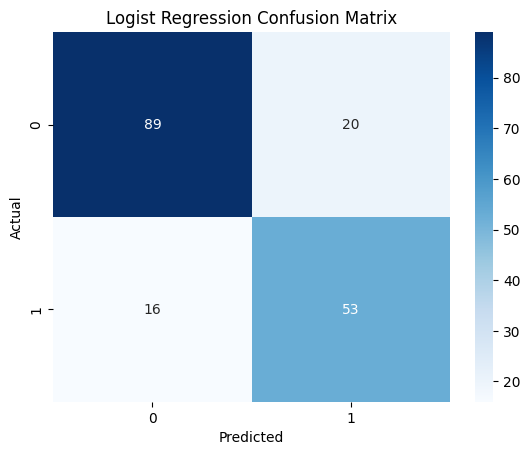

In [59]:
# Visualizing the confusion matrix

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logist Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [60]:
# Generating a classification report to evaluate model performance

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.82      0.83       109
           1       0.73      0.77      0.75        69

    accuracy                           0.80       178
   macro avg       0.79      0.79      0.79       178
weighted avg       0.80      0.80      0.80       178



In [61]:
# Importing the Decision Tree model

from sklearn.tree import DecisionTreeClassifier

In [62]:
# Creating the Decision Tree model

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

In [63]:
# Training the Decision Tree model

decision_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [64]:
# Making predictions with the Decision Tree model

y_pred_tree = decision_tree_model.predict(X_test)

In [65]:
# Evaluating Decision Tree accuracy

from sklearn.metrics import accuracy_score

tree_accuracy = accuracy_score(y_test, y_pred_tree)

print(tree_accuracy)

0.7359550561797753


In [66]:
# Analyzing Decision Tree errors using a confusion matrix

from sklearn.metrics import confusion_matrix

tree_conf_matrix = confusion_matrix(y_test, y_pred_tree)

print(tree_conf_matrix)

[[79 30]
 [17 52]]


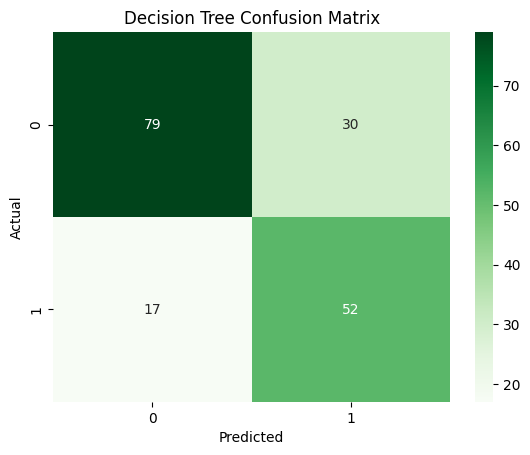

In [67]:
# Visualizing the Decision Tree confusion matrix

sns.heatmap(
    tree_conf_matrix,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [68]:
# Generating a classification report for the Decision Tree model

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.82      0.72      0.77       109
           1       0.63      0.75      0.69        69

    accuracy                           0.74       178
   macro avg       0.73      0.74      0.73       178
weighted avg       0.75      0.74      0.74       178



In [69]:
# Importing the Random Forest model

from sklearn.ensemble import RandomForestClassifier

In [70]:
# Creating the Random Forest model

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [71]:
# Training the Random Forest model

random_forest_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [72]:
# Making predictions with the Random Forest model

y_pred_forest = random_forest_model.predict(X_test)

In [73]:
# Evaluating Random Forest accuracy

from sklearn.metrics import accuracy_score

forest_accuracy = accuracy_score(y_test, y_pred_forest)

print(forest_accuracy)

0.797752808988764


In [74]:
# Analyzing Random Forest errors using a confusion matrix

from sklearn.metrics import confusion_matrix

forest_conf_matrix = confusion_matrix(y_test, y_pred_forest)

print(forest_conf_matrix)

[[93 16]
 [20 49]]


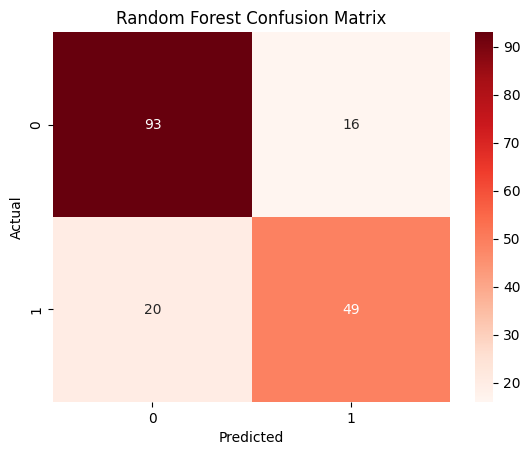

In [75]:
# Visualizing the Random Forest confusion matrix

sns.heatmap(
    forest_conf_matrix,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [76]:
# Generating a classification report for the Random Forest model

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_forest))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       109
           1       0.75      0.71      0.73        69

    accuracy                           0.80       178
   macro avg       0.79      0.78      0.78       178
weighted avg       0.80      0.80      0.80       178



In [77]:
# Model comparison summary:
#
# Logistic Regression showed the most balanced overall performance,
# achieving good accuracy while maintaining a better balance between
# false positives and false negatives.
#
# Decision Tree showed signs of overfitting and produced more classification errors.
#
# Random Forest improved the identification of non-survivors,
# but missed more actual survivors, making the model more conservative.
#
# Based on the overall balance between performance and interpretability,
# Logistic Regression was selected as the final model for predictions on the test dataset.

In [78]:
# Loading the test dataset

test = pd.read_csv('sample_data/test.csv')

In [79]:
# Inspecting the dataset structure

test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [80]:
# Displaying the first rows of the dataset

test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [81]:
# Creating age group categories based on passenger age

def categorize_age(age):
    if pd.isna(age):
        return 'Unknown'
    elif age <= 12:
        return 'Child'
    elif age <= 17:
        return 'Teenager'
    elif age <= 59:
        return 'Adult'
    else:
        return 'Elderly'

test['AgeGroup'] = test['Age'].apply(categorize_age)

In [82]:
display(test.head())

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Adult
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Adult
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Elderly
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Adult
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Adult


In [83]:
test['AgeGroup'].value_counts(dropna=False)

,count
AgeGroup,
Adult,277
Unknown,86
Child,25
Teenager,16
Elderly,14


In [84]:
# Setting a random seed for reproducibility

np.random.seed(42)

# Looping through each passenger class and sex group
# to probabilistically impute unknown age groups

for pclass in test['Pclass'].unique():
    for sex in test['Sex'].unique():

        # Filtering the current group
        group = test[
            (test['Pclass'] == pclass) &
            (test['Sex'] == sex)
        ]

        # Selecting passengers with known age groups
        known_groups = group[
            group['AgeGroup'] != 'Unknown'
        ]

        # Calculating age group proportions
        proportions = known_groups['AgeGroup'].value_counts(normalize=True)

        # Counting unknown age groups
        n_unknown = len(
            group[group['AgeGroup'] == 'Unknown']
        )

        # Generating probabilistic imputations
        random_age_groups = np.random.choice(
            proportions.index,
            size=n_unknown,
            p=proportions.values
        )

        # Replacing unknown age groups
        test.loc[
            (test['Pclass'] == pclass) &
            (test['Sex'] == sex) &
            (test['AgeGroup'] == 'Unknown'),
            'AgeGroup'
        ] = random_age_groups

In [85]:
test.describe(include='all')

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
count,418.000000,418.000000,418,418,332.000000,418.000000,418.000000,418,417.000000,91,418,418
unique,NaN,NaN,418,2,NaN,NaN,NaN,363,NaN,76,3,4
top,NaN,NaN,"Peter, Master. Michael J",male,NaN,NaN,NaN,PC 17608,NaN,B57 B59 B63 B66,S,Adult
freq,NaN,NaN,1,266,NaN,NaN,NaN,5,NaN,3,270,348
mean,1100.500000,2.265550,NaN,NaN,30.272590,0.447368,0.392344,NaN,35.627188,NaN,NaN,NaN
std,120.810458,0.841838,NaN,NaN,14.181209,0.896760,0.981429,NaN,55.907576,NaN,NaN,NaN
min,892.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN
25%,996.250000,1.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN,NaN
50%,1100.500000,3.000000,NaN,NaN,27.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN,NaN
75%,1204.750000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.500000,NaN,NaN,NaN


In [86]:
# Creating a binary feature indicating whether the passenger had a cabin registered

test['HasCabin'] = test['Cabin'].notna().astype(int)

In [87]:
test['HasCabin'].value_counts()

,count
HasCabin,
0,327
1,91


In [88]:
# Removing unnecessary columns from the test dataset for this model

test = test.drop(columns=['Age', 'Cabin', 'Name', 'Ticket'])

In [89]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    object 
 3   SibSp        418 non-null    int64  
 4   Parch        418 non-null    int64  
 5   Fare         417 non-null    float64
 6   Embarked     418 non-null    object 
 7   AgeGroup     418 non-null    object 
 8   HasCabin     418 non-null    int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 29.5+ KB


In [90]:
# Identifying the row with a missing Fare value

test[test['Fare'].isna()]

,PassengerId,Pclass,Sex,SibSp,Parch,Fare,Embarked,AgeGroup,HasCabin
152,1044,3,male,0,0,NaN,S,Elderly,0


In [91]:
test[
    (test['Pclass'] == 3) &
    (test['Sex'] == 'male')
]['Fare'].median()

7.8958

In [92]:
# Filling the missing Fare value using the median fare
# of passengers with similar characteristics

test['Fare'] = test['Fare'].fillna(7.8958)

In [93]:
# Checking for remaining missing values

test['Fare'].isna().sum()

np.int64(0)

In [94]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    object 
 3   SibSp        418 non-null    int64  
 4   Parch        418 non-null    int64  
 5   Fare         418 non-null    float64
 6   Embarked     418 non-null    object 
 7   AgeGroup     418 non-null    object 
 8   HasCabin     418 non-null    int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 29.5+ KB


In [95]:
# Applying One-Hot Encoding to categorical variables

test_encoded = pd.get_dummies(
    test,
    columns=['Sex', 'Embarked', 'AgeGroup'],
    drop_first=True
)

In [96]:
# Checking dataset structure after encoding

test_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PassengerId        418 non-null    int64  
 1   Pclass             418 non-null    int64  
 2   SibSp              418 non-null    int64  
 3   Parch              418 non-null    int64  
 4   Fare               418 non-null    float64
 5   HasCabin           418 non-null    int64  
 6   Sex_male           418 non-null    bool   
 7   Embarked_Q         418 non-null    bool   
 8   Embarked_S         418 non-null    bool   
 9   AgeGroup_Child     418 non-null    bool   
 10  AgeGroup_Elderly   418 non-null    bool   
 11  AgeGroup_Teenager  418 non-null    bool   
dtypes: bool(6), float64(1), int64(5)
memory usage: 22.2 KB


In [97]:
test_encoded.head()

,PassengerId,Pclass,SibSp,Parch,Fare,HasCabin,Sex_male,Embarked_Q,Embarked_S,AgeGroup_Child,AgeGroup_Elderly,AgeGroup_Teenager
0,892,3,0,0,7.8292,0,True,True,False,False,False,False
1,893,3,1,0,7.0000,0,False,False,True,False,False,False
2,894,2,0,0,9.6875,0,True,True,False,False,True,False
3,895,3,0,0,8.6625,0,True,False,True,False,False,False
4,896,3,1,1,12.2875,0,False,False,True,False,False,False


In [98]:
test_encoded.reindex()

,PassengerId,Pclass,SibSp,Parch,Fare,HasCabin,Sex_male,Embarked_Q,Embarked_S,AgeGroup_Child,AgeGroup_Elderly,AgeGroup_Teenager
0,892,3,0,0,7.8292,0,True,True,False,False,False,False
1,893,3,1,0,7.0000,0,False,False,True,False,False,False
2,894,2,0,0,9.6875,0,True,True,False,False,True,False
3,895,3,0,0,8.6625,0,True,False,True,False,False,False
4,896,3,1,1,12.2875,0,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,0,0,8.0500,0,True,False,True,False,False,False
414,1306,1,0,0,108.9000,1,False,False,False,False,False,False
415,1307,3,0,0,7.2500,0,True,False,True,False,False,False
416,1308,3,0,0,8.0500,0,True,False,True,False,False,False


In [99]:
# Aligning test dataset columns with training dataset columns

test_aligned = test_encoded.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [100]:
# Comparing train and test feature shapes

print(X_train.shape)
print(test_aligned.shape)

(711, 12)
(418, 12)


In [101]:
# Generating predictions for the test dataset

test_predictions = model.predict(test_aligned)

In [102]:
# Creating the submission dataframe

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions
})

In [103]:
# Displaying the first rows of the submission file

submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [104]:
# Exporting the submission file to CSV

submission.to_csv('submission.csv', index=False)

In [105]:
# Downloading the submission file

from google.colab import files

files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>